# Jet energy loss and the wake: parton and hydro level

The figures in this notebook come from **`wake_observables.h5`**, which
[`wake_observables.py`](wake_observables.py) writes in one pass over a production. The
notebook never opens the pair files, so adding a figure is a new cell here, not a new pass
over 75 GB. If a figure needs a quantity that is not in the file, add it to the script and
rerun it (about a minute for 300 events on 10 cores):

    python wake_observables.py /path/to/production -j 10 -o /path/to/production/wake_observables.h5

What the file holds (see the script's docstring for the details):

| table | one row per | main columns |
|---|---|---|
| `events` | jet event | pTHat window and its cross section, participant plane ψ₂ and ε₂ of the background, freeze-out times, energy totals |
| `showers` | shower (initial parton) | pid, E₀, pT₀, y₀, vertex, `cos_alpha`, `dphi_psi2`, the graph's energy bookkeeping, the path through the background medium |
| `droplets` | droplet | position, four-momentum, shower, background T at the deposit, `kernel_flux` |
| `evolution` | event × τ frame | P^μ and S of each leg through the τ surface, cumulative droplet four-momentum |
| `jetframe` | event | the wake about the leading-deposit leg's source in (Δη, Δφ) |

Everything here is at parton or hydro level: the "jet" is the initial parton, the "wake" is
$\Delta T^{\mu\nu}$ = jet leg − background.

> **Read §1 first.** MUSIC_2 does not receive the droplets' energy. The CausalLiquefier kernel
> is point-sampled at MUSIC's cell centres without normalization, so each droplet arrives with
> a factor `kernel_flux` that is close to 1 near η_s = 0, but ranges from ~0 to ~6 at large |η_s|
> or late τ. Parton-level results (§2–§6) do not depend on it. Hydro-level results (§7–§9)
> describe the wake MUSIC actually evolved, which is why they are normalised to
> `E_inj_hydro`, the kernel-weighted deposit, rather than to the droplet energy.

In [1]:
%matplotlib inline
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH = os.environ.get("WAKE_OBS",
                      "/home/putschke/FNO_Hydro_Data/AuAu_0_10_pth10-40_eta06/wake_observables.h5")

# --- one fixed visual language (as in ../prod_AuAu_0_10_jet/jet_wake.ipynb) ----------------
# Categories keep ASSIGNED colours (never cycled) plus a marker, so they survive greyscale.
KIND_C = {"quark": "#0072B2", "gluon": "#D55E00"}
KIND_M = {"quark": "o", "gluon": "s"}
BIN_C = ["#0072B2", "#009E73", "#E69F00", "#D55E00", "#CC79A7"]   # pT bins, in order
BIN_M = ["o", "s", "^", "D", "v"]
POS_C, NEG_C, HYD_C = "#D55E00", "#0072B2", "#009E73"
CMAP_DIFF = "RdBu_r"


def tidy(ax, xlabel=None, ylabel=None, title=None):
    """Recessive grid and spines, so the data is the most prominent thing in the frame."""
    ax.grid(True, alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title: ax.set_title(title, fontsize=10)
    return ax


plt.rcParams.update({"figure.dpi": 110, "font.size": 9.5, "axes.titlesize": 10,
                     "legend.frameon": False})


def load(path):
    with h5py.File(path, "r") as f:
        tab = lambda g: pd.DataFrame({k: f[g][k][:] for k in f[g]})
        out = dict(E=tab("events"), S=tab("showers"), D=tab("droplets"),
                   evo={k: f["evolution"][k][:] for k in f["evolution"]},
                   jf={k: f["jetframe"][k][:] for k in f["jetframe"]},
                   attrs=dict(f.attrs), files=[s.decode() for s in f["files"][:]])
    return out


W = load(PATH)
E, S, D, EVO, JF, A = W["E"], W["S"], W["D"], W["evo"], W["jf"], W["attrs"]
TAU = A["tau_min"] + A["dtau"] * np.arange(int(A["ntau"]))
T_C = float(A["T_C"])

# Weights.  With USE_XSEC_WEIGHTS each pTHat window counts with its cross section: right for
# inclusive distributions, but the windows' weights differ by ~1000x, so in a bin of the
# parton's own pT a single low-pTHat event can dominate.  For observables conditional on pT0
# the unweighted mean is the better estimator (same mean, far smaller variance), hence the
# default.
USE_XSEC_WEIGHTS = False
n_bin = E.groupby("pthat_bin").size()
sigma = E.groupby("pthat_bin").sigma_bin.mean()
E["w_xsec"] = (sigma / n_bin).reindex(E.pthat_bin).to_numpy() * E.event_weight
E["w_xsec"] /= E.w_xsec.mean()
E["w"] = E.w_xsec if USE_XSEC_WEIGHTS else 1.0

# Per event: the wake at the last frame both legs are live
live = np.minimum(E.ntau_jet, E.ntau_bg).to_numpy() - 1
dP = EVO["P_jet"] - EVO["P_bg"]
iev = np.arange(len(E))
E["dP0_last"] = dP[iev, live, 0]
E["dS_last"] = (EVO["S_jet"] - EVO["S_bg"])[iev, live]
E["dtau_fo"] = E.tau_fo_jet - E.tau_fo_bg

S = S.join(E[["w", "pthat_bin", "psi2", "eps2", "lead_leg_row"]], on="event")
S["kind"] = np.select([S.pid == 21, S.pid.abs() <= 6], ["gluon", "quark"], "photon")
S["frac_dep"] = S.E_dep_graph / S.E0
S["rank"] = S.groupby("event").pT0.rank(ascending=False, method="first").astype(int) - 1
S["is_lead_dep"] = S.index == S.lead_leg_row
D = D.join(E[["w"]], on="event")

# The selection most figures use: partons at midrapidity that can lose energy
MID = (S.kind != "photon") & (S.y0.abs() < 1.0)
PT_EDGES = np.array([2.0, 5.0, 10.0, 20.0, 45.0])
S["pt_bin"] = np.digitize(S.pT0, PT_EDGES) - 1


def pt_label(i):
    return f"{PT_EDGES[i]:g} < $p_{{T,0}}$ < {PT_EDGES[i + 1]:g} GeV"


def profile(x, y, edges, w=None, min_n=5):
    """Weighted mean of y and its standard error in bins of x (NaN where < min_n entries)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    w = np.ones_like(y) if w is None else np.asarray(w, float)
    idx = np.digitize(x, edges) - 1
    k = len(edges) - 1
    mu, err, n = np.full(k, np.nan), np.full(k, np.nan), np.zeros(k, int)
    for i in range(k):
        m = (idx == i) & np.isfinite(y) & np.isfinite(x)
        n[i] = m.sum()
        if n[i] < min_n:
            continue
        ww = w[m]
        mu[i] = np.average(y[m], weights=ww)
        neff = ww.sum() ** 2 / (ww ** 2).sum()
        err[i] = np.sqrt(np.average((y[m] - mu[i]) ** 2, weights=ww) / neff)
    return 0.5 * (edges[1:] + edges[:-1]), mu, err, n


def plot_profile(ax, x, y, edges, w, **kw):
    c, mu, err, n = profile(x, y, edges, w)
    ok = np.isfinite(mu)
    ax.errorbar(c[ok], mu[ok], yerr=err[ok], capsize=2, lw=1.4, ms=4, **kw)


print(f"{os.path.basename(PATH)}: {len(E)} events from {len(W['files'])} files, "
      f"{len(S)} showers, {len(D)} droplets  (written {A['created']})")
print("events per pTHat window:", {int(k): int(v) for k, v in n_bin.items()},
      "; cross-section weights:",
      {int(k): round(float(v), 3) for k, v in E.groupby("pthat_bin").w_xsec.first().items()},
      f"; used: {USE_XSEC_WEIGHTS}")
print(f"LBT double-count fix applied to all files: {bool(E.double_count_fix.all())}")
print(f"midrapidity partons (|y0| < 1, no photons): {MID.sum()}, of which "
      f"{(MID & (S.kind == 'quark')).sum()} quarks, {(MID & (S.kind == 'gluon')).sum()} gluons")

wake_observables.h5: 300 events from 20 files, 1209 showers, 6456 droplets  (written 2026-09-28 13:22:48)
events per pTHat window: {0: 100, 1: 100, 2: 100} ; cross-section weights: {0: 2.938, 1: 0.059, 2: 0.003} ; used: False
LBT double-count fix applied to all files: True
midrapidity partons (|y0| < 1, no photons): 805, of which 318 quarks, 487 gluons


## 1. Validation

Three things have to hold before anything below means something:

1. every droplet is assigned to its shower (through the graph, not geometrically);
2. the energy balance of §11 in `jet_wake.ipynb` closes for every shower:
   $E_0 = E_\text{surviving} + \Delta E$, where ΔE = absorbed + missing − holes;
3. what MUSIC_2 received is known.

Item 3 is where the surprise is. For each droplet, the script sums the CausalLiquefier kernel
over MUSIC's cell centres on the step that deposits it (`KernelFlux`, a port of
`CausalLiquefier::smearing_kernel`). In the continuum that sum is 1. On the grid it is only
close to 1 when the kernel spans many cells. The kernel is a ball of radius
$c_\text{diff}(t - t_d)$. A droplet at $\eta_d$ is seen at $t - t_d \approx \cosh\eta_d\,
\tau_\text{delay}$, and in lab $z$ one η cell is $\tau\,\Delta\eta\cosh\eta$ long. So both large
$|\eta_d|$ and late τ leave the ball on a few cells, and the sampled sum can be anything from
~0 to several. The right panel checks the port against the hydro: the wake's $\Delta P^0$ follows
the kernel-weighted deposit, not the droplet energy.

(1) droplets not assigned to a shower: 0 of 6456; max |graph - droplets| per shower 1.4e-06 GeV
(2) max |E0 - E_surv - dE| per shower: 9.9e-14 GeV
(3) kernel flux of injected droplets: median 1.002; energy-weighted mean 0.970; outside [0.8, 1.2]: 27% of droplets
    per event E_inj_hydro / E_droplets: median 0.96, 16-84% 0.69 .. 1.12, min -1.89, max 5.95


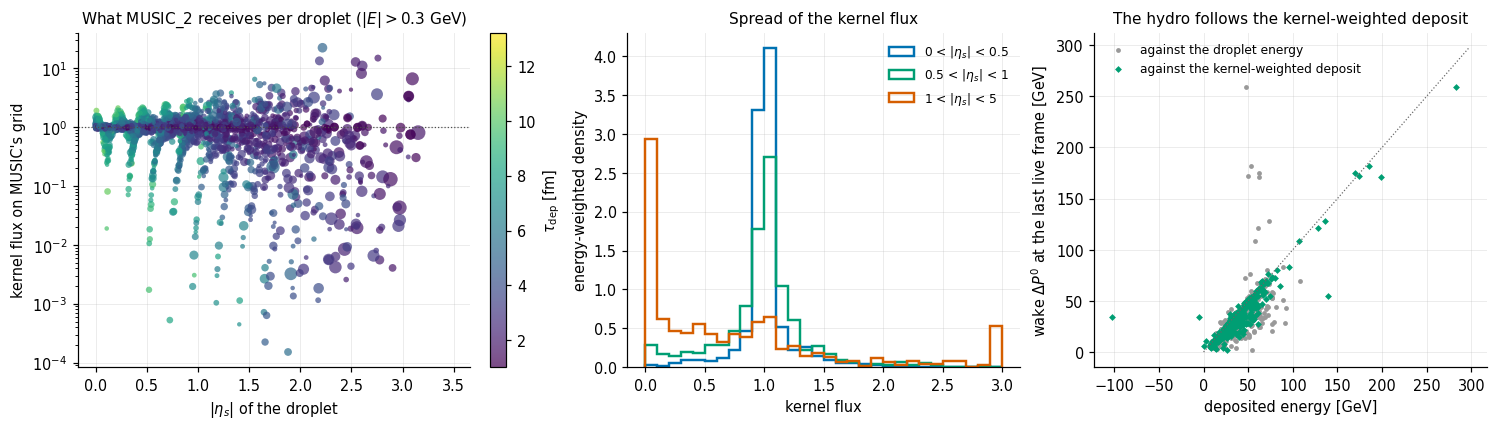

corr(dP0_last, droplet energy) = 0.518; median dP0_last / it = 0.783
corr(dP0_last, kernel-weighted) = 0.920; median dP0_last / it = 0.883


In [2]:
res = (S.E0 - S.E_surv - S.E_dep_graph).abs()
print(f"(1) droplets not assigned to a shower: {int(E.n_drop_unassigned.sum())} of {len(D)}; "
      f"max |graph - droplets| per shower {np.abs(S.E_dep_graph - S.E_dep_drop).max():.1e} GeV")
print(f"(2) max |E0 - E_surv - dE| per shower: {res.max():.1e} GeV")
inj = D[D.injected]
print(f"(3) kernel flux of injected droplets: median {inj.kernel_flux.median():.3f}; energy-"
      f"weighted mean {np.average(inj.kernel_flux, weights=inj.E.abs()):.3f}; "
      f"outside [0.8, 1.2]: {((inj.kernel_flux < 0.8) | (inj.kernel_flux > 1.2)).mean():.0%} "
      f"of droplets")
r = E.E_inj_hydro / E.E_drop_injected
print(f"    per event E_inj_hydro / E_droplets: median {r.median():.2f}, "
      f"16-84% {r.quantile(0.16):.2f} .. {r.quantile(0.84):.2f}, min {r.min():.2f}, max {r.max():.2f}")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
big = inj[inj.E.abs() > 0.3]
sc = ax[0].scatter(big.eta.abs(), big.kernel_flux, c=big.tau_dep, s=6 + 3 * big.E.abs(),
                   cmap="viridis", alpha=0.7, lw=0)
fig.colorbar(sc, ax=ax[0], label=r"$\tau_\mathrm{dep}$ [fm]", fraction=0.05)
ax[0].axhline(1, color="0.3", lw=0.8, ls=":")
ax[0].set_yscale("log")
tidy(ax[0], r"$|\eta_s|$ of the droplet", "kernel flux on MUSIC's grid",
     "What MUSIC_2 receives per droplet ($|E| > 0.3$ GeV)")
bins = np.linspace(0, 3, 31)
for lo, hi, c in ((0.0, 0.5, BIN_C[0]), (0.5, 1.0, BIN_C[1]), (1.0, 5.0, BIN_C[3])):
    m = (inj.eta.abs() >= lo) & (inj.eta.abs() < hi)
    ax[1].hist(inj.kernel_flux[m].clip(0, 2.99), bins=bins, weights=inj.E.abs()[m],
               histtype="step", lw=1.6, color=c, label=rf"{lo:g} < $|\eta_s|$ < {hi:g}",
               density=True)
tidy(ax[1], "kernel flux", "energy-weighted density", "Spread of the kernel flux")
ax[1].legend(fontsize=8)
lim = max(E.E_drop_injected.max(), E.E_inj_hydro.max(), E.dP0_last.max()) * 1.05
ax[2].plot([0, lim], [0, lim], color="0.4", lw=0.8, ls=":")
ax[2].scatter(E.E_drop_injected, E.dP0_last, s=10, color="0.6", marker="o", lw=0,
              label="against the droplet energy")
ax[2].scatter(E.E_inj_hydro, E.dP0_last, s=10, color=HYD_C, marker="D", lw=0,
              label="against the kernel-weighted deposit")
tidy(ax[2], "deposited energy [GeV]", r"wake $\Delta P^0$ at the last live frame [GeV]",
     "The hydro follows the kernel-weighted deposit")
ax[2].legend(fontsize=8)
plt.show()

for label, x in (("droplet energy", E.E_drop_injected), ("kernel-weighted", E.E_inj_hydro)):
    print(f"corr(dP0_last, {label}) = {np.corrcoef(x, E.dP0_last)[0, 1]:.3f}; "
          f"median dP0_last / it = {np.median(E.dP0_last / x):.3f}")

## 2. Energy loss against the parton's pT

ΔE comes from the shower graph (absorbed + missing − holes) and is exact per shower. The
fraction ΔE/E₀ is what quenching models predict. The absolute ΔE shows how the loss grows with
pT. Quark and gluon initiators are split, since the colour factor ($C_A/C_F$ = 9/4) should
separate them. The right panel shows the whole distribution in pT bins: fluctuations of the
loss, not only its mean, drive surface bias.

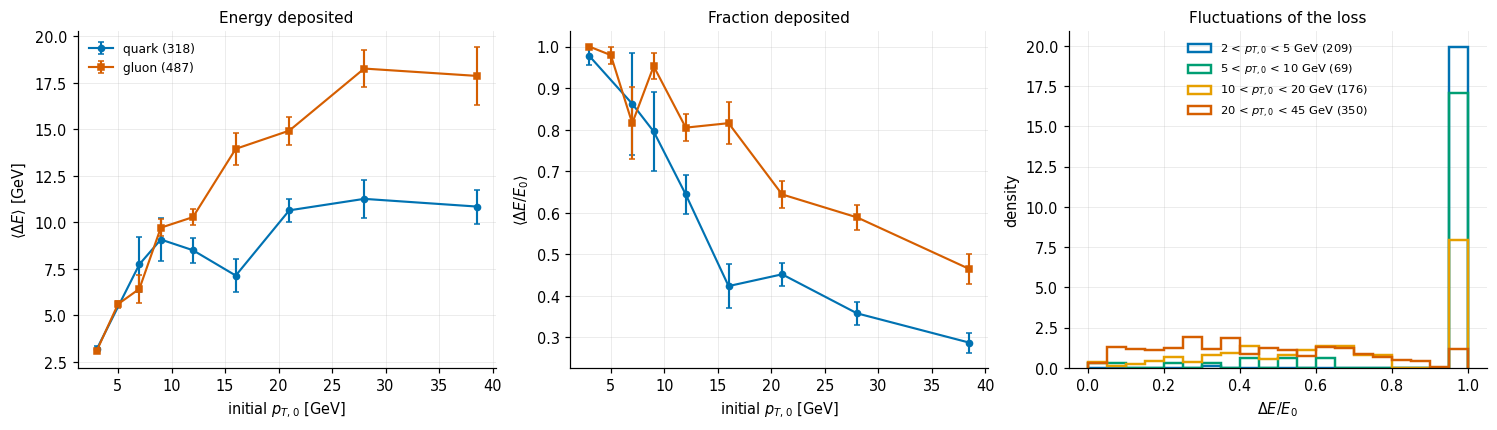

pT0 > 10 GeV: <dE/E0> quark 0.408, gluon 0.653; fully absorbed (dE/E0 > 0.99): 17.1%


In [3]:
edges = np.array([2, 4, 6, 8, 10, 14, 18, 24, 32, 45.0])
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
for kind in ("quark", "gluon"):
    m = MID & (S.kind == kind)
    kw = dict(color=KIND_C[kind], marker=KIND_M[kind], label=f"{kind} ({m.sum()})")
    plot_profile(ax[0], S.pT0[m], S.E_dep_graph[m], edges, S.w[m], **kw)
    plot_profile(ax[1], S.pT0[m], S.frac_dep[m], edges, S.w[m], **kw)
tidy(ax[0], r"initial $p_{T,0}$ [GeV]", r"$\langle\Delta E\rangle$ [GeV]", "Energy deposited")
tidy(ax[1], r"initial $p_{T,0}$ [GeV]", r"$\langle\Delta E / E_0\rangle$", "Fraction deposited")
ax[0].legend(fontsize=8)
bins = np.linspace(0, 1.0001, 21)
for i in range(len(PT_EDGES) - 1):
    m = MID & (S.pt_bin == i)
    if m.sum() < 10:
        continue
    ax[2].hist(S.frac_dep[m], bins=bins, weights=S.w[m], density=True, histtype="step",
               lw=1.6, color=BIN_C[i], label=f"{pt_label(i)} ({m.sum()})")
tidy(ax[2], r"$\Delta E / E_0$", "density", "Fluctuations of the loss")
ax[2].legend(fontsize=7.5, loc="upper center")
plt.show()
m = MID & (S.pT0 > 10)
print(f"pT0 > 10 GeV: <dE/E0> quark {np.average(S.frac_dep[m & (S.kind == 'quark')], weights=S.w[m & (S.kind == 'quark')]):.3f}, "
      f"gluon {np.average(S.frac_dep[m & (S.kind == 'gluon')], weights=S.w[m & (S.kind == 'gluon')]):.3f}; "
      f"fully absorbed (dE/E0 > 0.99): {np.average(S.frac_dep[m] > 0.99, weights=S.w[m]):.1%}")

### Holes and recoils in the deposit

The net deposit is what the absorbed partons carry *minus* the holes, the medium partons that
recoils took with them. The holes are a sizeable part, so the net value hides a lot.

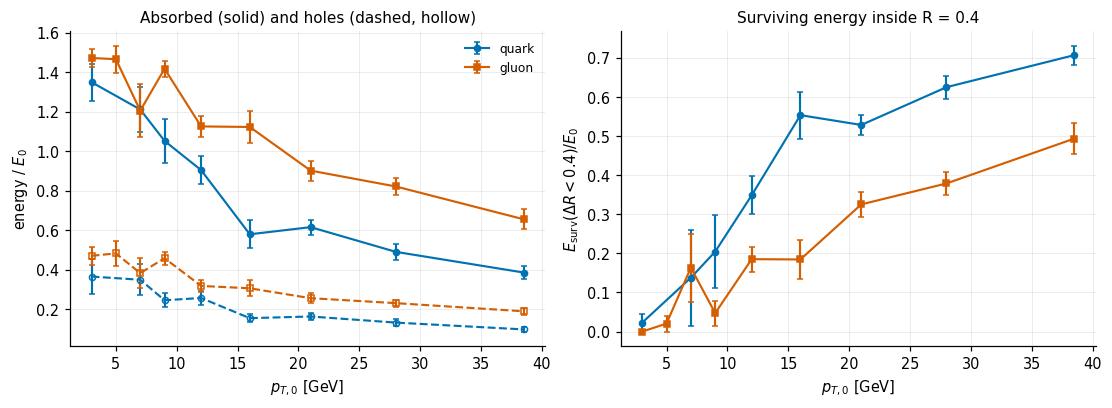

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
for kind in ("quark", "gluon"):
    m = MID & (S.kind == kind)
    kw = dict(color=KIND_C[kind], marker=KIND_M[kind], label=kind)
    plot_profile(ax[0], S.pT0[m], S.E_absorbed[m] / S.E0[m], edges, S.w[m], **kw)
    plot_profile(ax[0], S.pT0[m], S.E_holes[m] / S.E0[m], edges, S.w[m],
                 **dict(kw, label=None, ls="--", mfc="none"))
    plot_profile(ax[1], S.pT0[m], S.E_surv_R04[m] / S.E0[m], edges, S.w[m], **kw)
tidy(ax[0], r"$p_{T,0}$ [GeV]", r"energy / $E_0$",
     "Absorbed (solid) and holes (dashed, hollow)")
tidy(ax[1], r"$p_{T,0}$ [GeV]", r"$E_\mathrm{surv}(\Delta R < 0.4) / E_0$",
     "Surviving energy inside R = 0.4")
ax[0].legend(fontsize=8)
plt.show()

## 3. Geometry: into or out of the fireball, in or out of plane

`cos_alpha` = $\hat r\cdot\hat n$ at the vertex, measured from the fireball's centre (energy
density at |η| < 0.5, τ₀). It is +1 for a parton heading out through the nearest edge and −1
for one heading through the centre. `dphi_psi2` is the angle to the background's participant
plane, folded into [0, π/2]: 0 is in plane (the short axis), π/2 out of plane. In 0–10% ε₂ is
small, so the in/out-of-plane difference is expected to be weak. It is shown split by ε₂.

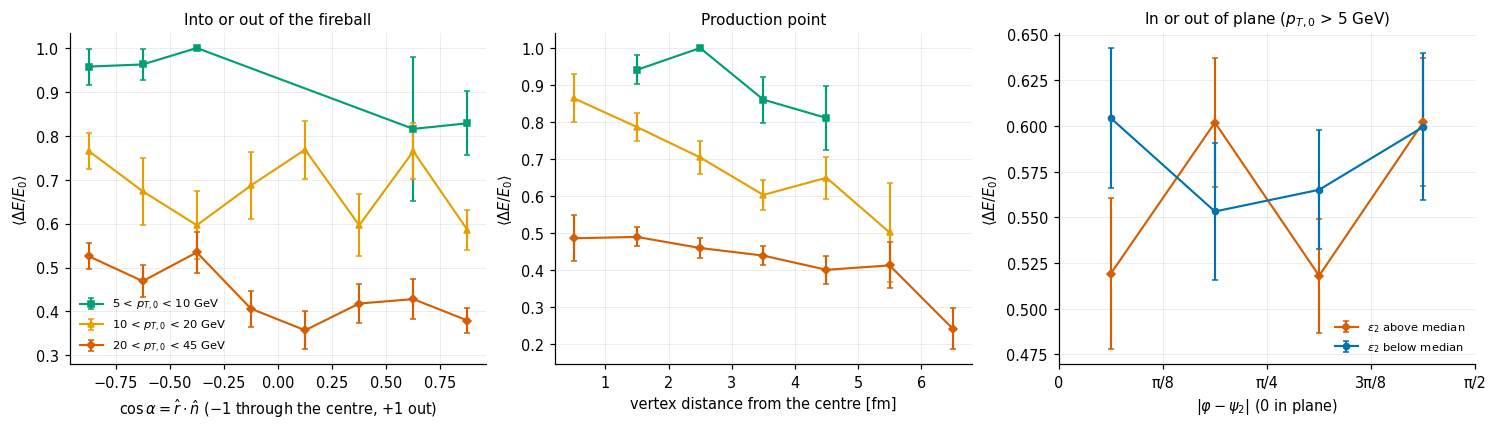

eps2 of the backgrounds: [0.026 0.056 0.071 0.073 0.086 0.088 0.089 0.101 0.115 0.127 0.136 0.137
 0.153 0.159 0.163 0.172 0.18  0.217 0.301 0.351]


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
ca = np.linspace(-1, 1, 9)
for i in (1, 2, 3):
    m = MID & (S.pt_bin == i)
    plot_profile(ax[0], S.cos_alpha[m], S.frac_dep[m], ca, S.w[m], color=BIN_C[i],
                 marker=BIN_M[i], label=pt_label(i))
tidy(ax[0], r"$\cos\alpha = \hat r\cdot\hat n$ (−1 through the centre, +1 out)",
     r"$\langle\Delta E/E_0\rangle$", "Into or out of the fireball")
ax[0].legend(fontsize=7.5)
rv = np.linspace(0, 7, 8)
for i in (1, 2, 3):
    m = MID & (S.pt_bin == i)
    plot_profile(ax[1], S.r_vtx[m], S.frac_dep[m], rv, S.w[m], color=BIN_C[i], marker=BIN_M[i])
tidy(ax[1], "vertex distance from the centre [fm]", r"$\langle\Delta E/E_0\rangle$",
     "Production point")
dp = np.linspace(0, np.pi / 2, 5)
e2 = S.eps2 > S.eps2.median()
for lab, sel, c, mk in (("$\\varepsilon_2$ above median", e2, BIN_C[3], "D"),
                        ("$\\varepsilon_2$ below median", ~e2, BIN_C[0], "o")):
    m = MID & (S.pT0 > 5) & sel
    plot_profile(ax[2], S.dphi_psi2[m], S.frac_dep[m], dp, S.w[m], color=c, marker=mk,
                 label=lab)
ax[2].set_xticks([0, np.pi / 8, np.pi / 4, 3 * np.pi / 8, np.pi / 2],
                 ["0", "π/8", "π/4", "3π/8", "π/2"])
tidy(ax[2], r"$|\varphi - \psi_2|$ (0 in plane)", r"$\langle\Delta E/E_0\rangle$",
     r"In or out of plane ($p_{T,0}$ > 5 GeV)")
ax[2].legend(fontsize=7.5)
plt.show()
print(f"eps2 of the backgrounds: {np.unique(E.eps2.round(3))}")

## 4. Path length and the medium along the path

The path is the parton's straight line through the **background** medium (the energy loss
runs on MUSIC_1's medium, so `arr` would already contain the wake), from $\tau$ = 0.5 fm
until $T < T_c$ = 0.16 GeV. Line integrals along it:

| column | integral | expected for |
|---|---|---|
| `L` | $\int d\tau\,\Theta(T > T_c)$ | path length |
| `I_T2` | $\int d\tau\, T^2$ | collisional loss (∝ L) |
| `I_T3` | $\int d\tau\, T^3$ | radiative, ∝ $\hat q\,L$ |
| `I_T3L` | $\int d\tau\,(\tau - \tau_\text{in})\, T^3$ | radiative, ∝ $\hat q\,L^2$ (BDMPS-like) |
| `*_flow` | the same with $\gamma(1 - \vec v\cdot\hat n)$ | rates in the fluid rest frame: flow along the jet reduces the loss |

Which integral makes ΔE line up best is a test of what Matter + LBT do. The bars are the
correlation coefficient of ΔE with each integral, per pT bin. A pT bin fixes the energy, so the
correlation measures only the path dependence.

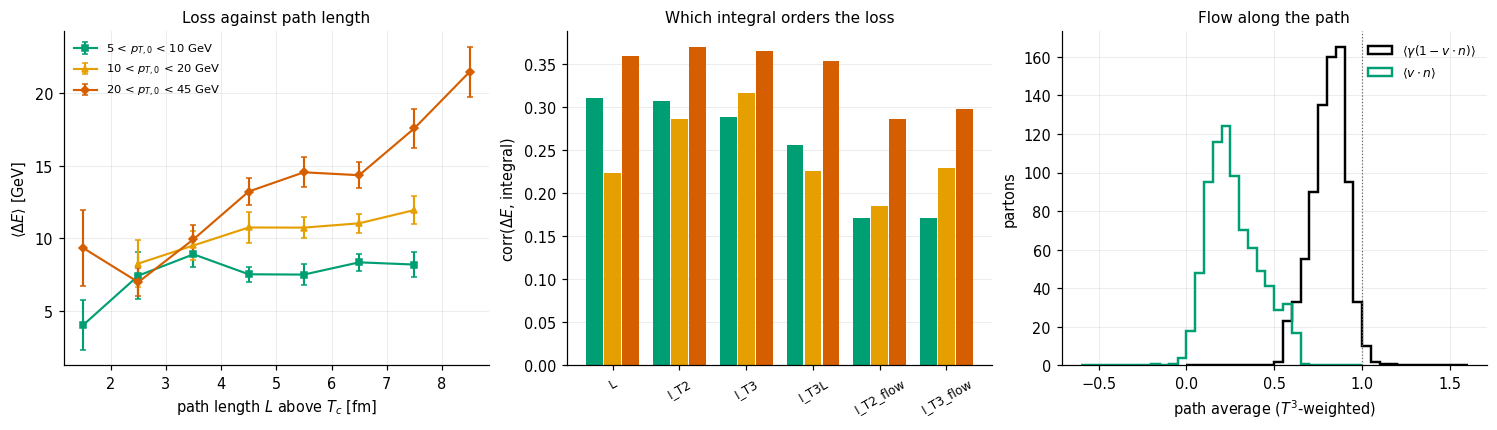

In [6]:
cols = ["L", "I_T2", "I_T3", "I_T3L", "I_T2_flow", "I_T3_flow"]
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
le = np.linspace(0, 9, 10)
for i in (1, 2, 3):
    m = MID & (S.pt_bin == i)
    plot_profile(ax[0], S.L[m], S.E_dep_graph[m], le, S.w[m], color=BIN_C[i], marker=BIN_M[i],
                 label=pt_label(i))
tidy(ax[0], r"path length $L$ above $T_c$ [fm]", r"$\langle\Delta E\rangle$ [GeV]",
     "Loss against path length")
ax[0].legend(fontsize=7.5)
xw = np.arange(len(cols))
for j, i in enumerate((1, 2, 3)):
    m = MID & (S.pt_bin == i)
    r = [np.corrcoef(S[c][m], S.E_dep_graph[m])[0, 1] for c in cols]
    ax[1].bar(xw + (j - 1) * 0.27, r, width=0.25, color=BIN_C[i], label=pt_label(i))
ax[1].set_xticks(xw, cols, rotation=30, fontsize=8)
tidy(ax[1], None, r"corr($\Delta E$, integral)", "Which integral orders the loss")
ax[1].grid(axis="x", visible=False)
m = MID & np.isfinite(S.flow_mean)
ax[2].hist(S.flow_mean[m], bins=np.linspace(0, 1.6, 33), weights=S.w[m], histtype="step",
           lw=1.6, color="k", label=r"$\langle\gamma(1 - v\cdot n)\rangle$")
ax[2].hist(S.vpar_mean[m], bins=np.linspace(-0.6, 1.0, 33), weights=S.w[m], histtype="step",
           lw=1.6, color=HYD_C, label=r"$\langle v\cdot n\rangle$")
ax[2].axvline(1, color="0.4", lw=0.8, ls=":")
tidy(ax[2], r"path average ($T^3$-weighted)", "partons", "Flow along the path")
ax[2].legend(fontsize=8)
plt.show()

## 5. Dijet asymmetry

Every event has at least two showers. For the two with the highest initial pT, the asymmetry
of what survives is
$A_J = (E_{\text{surv},1} - E_{\text{surv},2})/(E_{\text{surv},1} + E_{\text{surv},2})$. It is
compared with the asymmetry of the initial energies, so that loss is separated from what PYTHIA
produced. Plotted against the difference in path length, it maps surface bias directly.

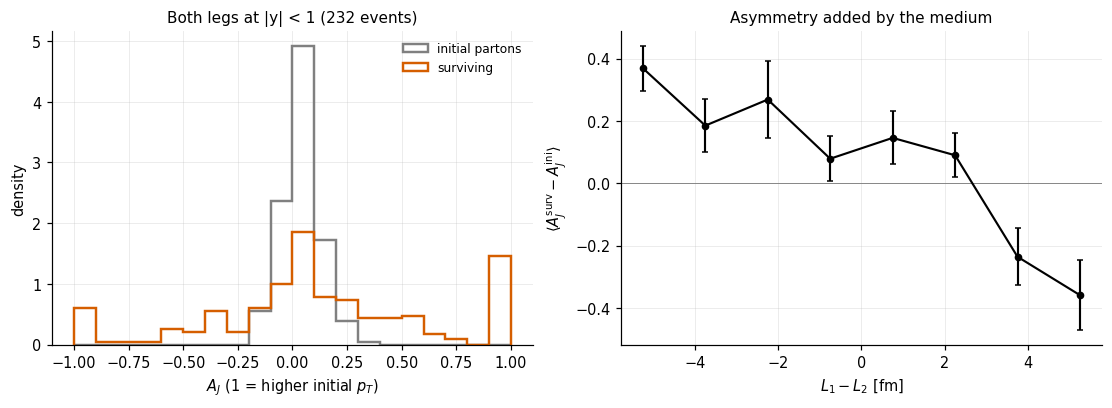

In [7]:
two = S[S["rank"] < 2].pivot(index="event", columns="rank")
AJ = pd.DataFrame({
    "AJ_surv": (two.E_surv[0] - two.E_surv[1]) / (two.E_surv[0] + two.E_surv[1]).clip(1e-9),
    "AJ_ini": (two.E0[0] - two.E0[1]) / (two.E0[0] + two.E0[1]),
    "dL": two.L[0] - two.L[1], "dI": two.I_T3L[0] - two.I_T3L[1],
    "mid": (two.y0[0].abs() < 1) & (two.y0[1].abs() < 1) & (two.pid[0] != 22) & (two.pid[1] != 22),
    "w": two.w[0]})
AJ = AJ[AJ.mid]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
b = np.linspace(-1, 1, 21)
ax[0].hist(AJ.AJ_ini, bins=b, weights=AJ.w, histtype="step", lw=1.6, color="0.5",
           label="initial partons", density=True)
ax[0].hist(AJ.AJ_surv, bins=b, weights=AJ.w, histtype="step", lw=1.6, color=POS_C,
           label="surviving", density=True)
tidy(ax[0], r"$A_J$ (1 = higher initial $p_T$)", "density", f"Both legs at |y| < 1 ({len(AJ)} events)")
ax[0].legend(fontsize=8)
plot_profile(ax[1], AJ.dL, AJ.AJ_surv - AJ.AJ_ini, np.linspace(-6, 6, 9), AJ.w, color="k",
             marker="o")
ax[1].axhline(0, color="0.5", lw=0.6)
tidy(ax[1], r"$L_1 - L_2$ [fm]", r"$\langle A_J^\mathrm{surv} - A_J^\mathrm{ini}\rangle$",
     "Asymmetry added by the medium")
plt.show()

## 6. When and where the energy goes in

Deposition time $\tau_\text{dep} = \tau_\text{droplet} + \tau_\text{delay}$, and the background
temperature at the deposit. Positive droplets (absorbed partons) and negative ones (holes
dominate) are shown separately. Energy deposited below $T_c$ goes into a medium that is close
to freezing out. Energy deposited after MUSIC_2 stopped is never injected.

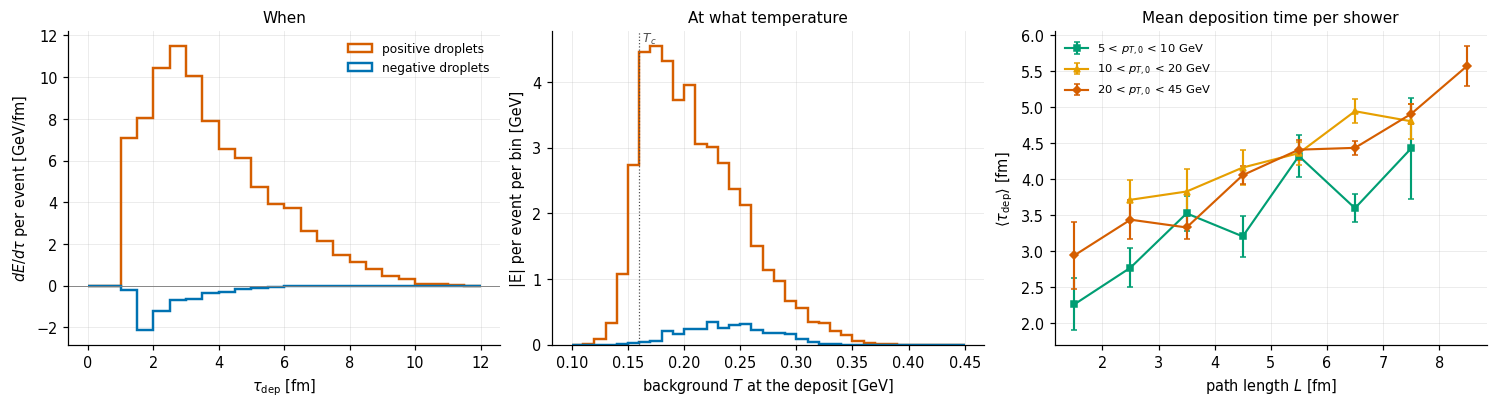

positive deposit below T_c: 9.5%;  never injected (after MUSIC_2 stopped): 0.08% of the energy


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6), constrained_layout=True)
tb = np.arange(0, 12.01, 0.5)
n_ev = E.w.sum()
for sgn, c, lab in ((1, POS_C, "positive droplets"), (-1, NEG_C, "negative droplets")):
    m = np.sign(D.E) == sgn
    ax[0].hist(D.tau_dep[m], bins=tb, weights=D.E[m] * D.w[m] / n_ev / 0.5, histtype="step",
               lw=1.6, color=c, label=lab)
ax[0].axhline(0, color="0.5", lw=0.6)
tidy(ax[0], r"$\tau_\mathrm{dep}$ [fm]", r"$dE/d\tau$ per event [GeV/fm]", "When")
ax[0].legend(fontsize=8)
Tb = np.linspace(0.10, 0.45, 36)
for sgn, c in ((1, POS_C), (-1, NEG_C)):
    m = (np.sign(D.E) == sgn) & np.isfinite(D.T_bg)
    ax[1].hist(D.T_bg[m], bins=Tb, weights=np.abs(D.E[m]) * D.w[m] / n_ev, histtype="step",
               lw=1.6, color=c)
ax[1].axvline(T_C, color="0.3", lw=0.8, ls=":")
ax[1].text(T_C, ax[1].get_ylim()[1], " $T_c$", va="top", fontsize=8, color="0.3")
tidy(ax[1], r"background $T$ at the deposit [GeV]", "|E| per event per bin [GeV]",
     "At what temperature")
for i in (1, 2, 3):
    m = MID & (S.pt_bin == i) & np.isfinite(S.tau_dep_mean)
    plot_profile(ax[2], S.L[m], S.tau_dep_mean[m], np.linspace(0, 9, 10), S.w[m],
                 color=BIN_C[i], marker=BIN_M[i], label=pt_label(i))
tidy(ax[2], "path length $L$ [fm]", r"$\langle\tau_\mathrm{dep}\rangle$ [fm]",
     "Mean deposition time per shower")
ax[2].legend(fontsize=7.5)
plt.show()
pos = D.E > 0
f_below = np.average(D.T_bg[pos & np.isfinite(D.T_bg)] < T_C,
                     weights=(D.E * D.w)[pos & np.isfinite(D.T_bg)])
print(f"positive deposit below T_c: {f_below:.1%};  never injected (after MUSIC_2 stopped): "
      f"{(D.E[~D.injected] * D.w[~D.injected]).sum() / (D.E * D.w).sum():.2%} of the energy")

## 7. The wake's four-momentum and entropy

$\Delta P^\mu(\tau)$ = jet leg − background, integrated through each τ surface with the
ideal-fluid $T^{\mu\nu}$. Up to the viscous stress (not stored) and what leaves the
output window, it has to follow what MUSIC_2 received. That is `D_hydro`, the kernel-weighted
droplets. The left panel shows the ratio averaged over events, once the deposit exceeds 5 GeV.

Entropy: a droplet with four-momentum $p$ that thermalizes in fluid moving with $u$ at
temperature $T$ produces $\Delta S = (p\cdot u)/T$, which for a deposit along the flow is less
than $E/T$. The right panel compares the wake's $\Delta S$ with that sum over the droplets
(kernel-weighted, background $T$ and $u$ at each deposit). Viscous entropy production in MUSIC
comes on top of it.

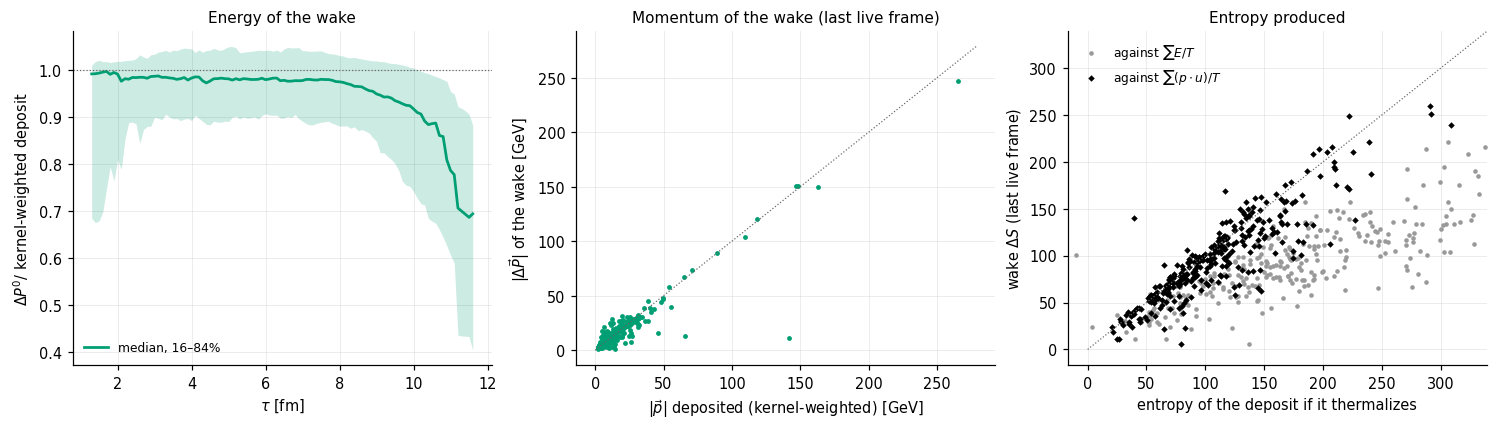

last live frame: median dP0 / kernel-weighted 0.883; momentum along the deposit: median 0.939
entropy: median dS / sum (p.u)/T = 0.93, dS / sum E/T = 0.54


In [9]:
Dh = EVO["D_hydro"][..., 0]
with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(Dh > 5.0, dP[..., 0] / Dh, np.nan)
for i, k in enumerate(live):
    ratio[i, k + 1:] = np.nan
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
okt = np.sum(np.isfinite(ratio), axis=0) >= 20
q = np.full((3, ratio.shape[1]), np.nan)
q[:, okt] = np.nanpercentile(ratio[:, okt], [16, 50, 84], axis=0)
ax[0].fill_between(TAU[okt], q[0][okt], q[2][okt], color=HYD_C, alpha=0.2, lw=0)
ax[0].plot(TAU[okt], q[1][okt], color=HYD_C, lw=1.8, label="median, 16–84%")
ax[0].axhline(1, color="0.4", lw=0.8, ls=":")
tidy(ax[0], r"$\tau$ [fm]", r"$\Delta P^0 / $ kernel-weighted deposit", "Energy of the wake")
ax[0].legend(fontsize=8)

pw = np.einsum("ij,ij->i", dP[iev, live, 1:], EVO["D_hydro"][iev, live, 1:]) / \
     np.linalg.norm(EVO["D_hydro"][iev, live, 1:], axis=1).clip(1e-9) ** 2
ax[1].scatter(np.linalg.norm(EVO["D_hydro"][iev, live, 1:], axis=1),
              np.linalg.norm(dP[iev, live, 1:], axis=1), s=10, color=HYD_C, lw=0)
lim = ax[1].get_xlim()[1]
ax[1].plot([0, lim], [0, lim], color="0.4", lw=0.8, ls=":")
tidy(ax[1], r"$|\vec p|$ deposited (kernel-weighted) [GeV]", r"$|\Delta\vec P|$ of the wake [GeV]",
     "Momentum of the wake (last live frame)")

# a droplet p that thermalizes in fluid moving with u makes entropy (p.u)/T, p.u = gamma (E - v.p)
dd = D[D.injected & np.isfinite(D.T_bg) & (D.T_bg > 0)]
vv = dd[["vx_bg", "vy_bg", "vz_bg"]].to_numpy()
gam = 1 / np.sqrt(np.clip(1 - (vv ** 2).sum(axis=1), 1e-9, None))
pu = gam * (dd.E - (vv * dd[["px", "py", "pz"]].to_numpy()).sum(axis=1))
E["dS_pred"] = (dd.kernel_flux * pu / dd.T_bg).groupby(dd.event).sum().reindex(E.index).fillna(0)
E["dS_pred_E"] = (dd.kernel_flux * dd.E / dd.T_bg).groupby(dd.event).sum().reindex(E.index).fillna(0)
ax[2].scatter(E.dS_pred_E, E.dS_last, s=9, color="0.6", lw=0, label=r"against $\sum E/T$")
ax[2].scatter(E.dS_pred, E.dS_last, s=9, color="k", lw=0, marker="D",
              label=r"against $\sum (p\cdot u)/T$")
lim = np.nanmax([E.dS_pred.max(), E.dS_last.max()]) * 1.1
ax[2].plot([0, lim], [0, lim], color="0.4", lw=0.8, ls=":")
ax[2].set(xlim=(-0.05 * lim, lim), ylim=(-0.05 * lim, lim))
tidy(ax[2], "entropy of the deposit if it thermalizes", r"wake $\Delta S$ (last live frame)",
     "Entropy produced")
ax[2].legend(fontsize=8)
plt.show()
print(f"last live frame: median dP0 / kernel-weighted {np.nanmedian(E.dP0_last / E.E_inj_hydro):.3f}; "
      f"momentum along the deposit: median {np.median(pw):.3f}")
okS = E.dS_pred > 20
print(f"entropy: median dS / sum (p.u)/T = {np.median(E.dS_last[okS] / E.dS_pred[okS]):.2f}, "
      f"dS / sum E/T = {np.median(E.dS_last[okS] / E.dS_pred_E[okS]):.2f}")

## 8. The stacked wake in the jet frame

The wake of every event, about the source of its leading-deposit leg: Δη from the source,
Δφ its spatial azimuth about the source position, with 0 = the leg's initial direction.
These are *spatial* angles, as in §5 of `jet_wake.ipynb`, not hadron momenta. Each event's
map contains the whole event's wake, other legs included. Each map is normalised to that
event's kernel-weighted deposit before stacking, so the stack is a shape. Top: while the leg
still deposits. Bottom: the last frame both legs are live.

The Δφ profiles in the right column are the hydro-level version of the missing-pT and energy-
recovery measurements. Energy (dP⁰) and momentum along the jet (dP·n) are shown per Δφ bin,
over |Δη| < 1.

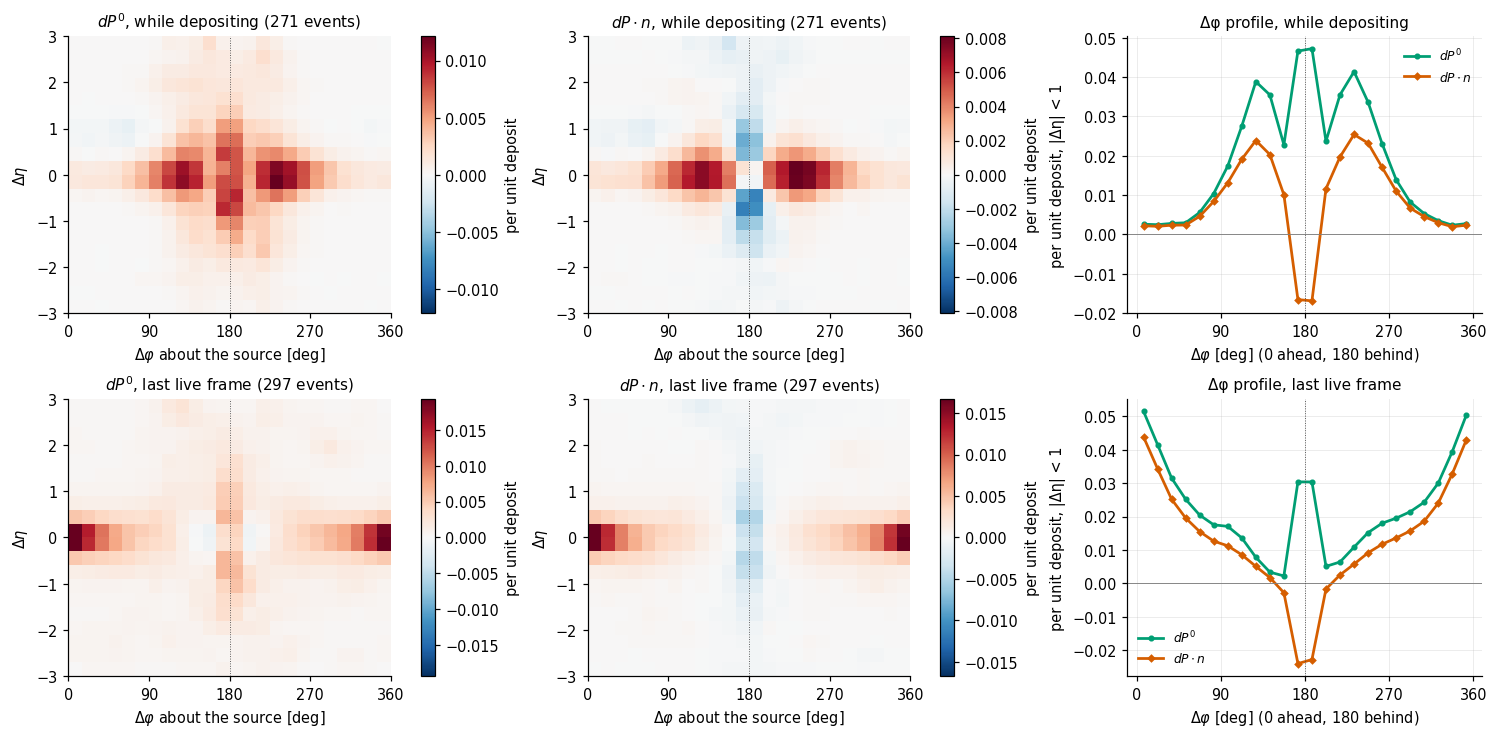

tau of the 'while depositing' frame: median 5.3 fm; c_s at the source there: median 0.391 (Mach half-angle 23 deg)


In [10]:
de, dph = A["deta_edges"], A["dphi_edges"]
dphc = np.degrees(0.5 * (dph[1:] + dph[:-1]))
band = np.abs(0.5 * (de[1:] + de[:-1])) < 1.0
norm = E.E_inj_hydro.to_numpy()
fig, ax = plt.subplots(2, 3, figsize=(13.5, 6.6), constrained_layout=True,
                       gridspec_kw={"width_ratios": [1, 1, 1.1]})
for j, what in enumerate(("while depositing", "last live frame")):
    mp = JF["maps"][:, j]                                  # (event, quantity, deta, dphi)
    ok = np.isfinite(mp).all(axis=(1, 2, 3)) & (norm > 2)
    stack = np.average(mp[ok] / norm[ok, None, None, None], axis=0, weights=E.w[ok])
    for c, name in enumerate((r"$dP^0$", r"$dP\cdot n$")):
        v = np.abs(stack[c]).max()
        im = ax[j, c].pcolormesh(np.degrees(dph), de, stack[c], cmap=CMAP_DIFF, vmin=-v, vmax=v,
                                 shading="auto")
        ax[j, c].axvline(180, color="0.3", lw=0.6, ls=":")
        ax[j, c].set_xticks([0, 90, 180, 270, 360])
        tidy(ax[j, c], r"$\Delta\varphi$ about the source [deg]", r"$\Delta\eta$",
             f"{name}, {what} ({ok.sum()} events)")
        ax[j, c].grid(False)
        fig.colorbar(im, ax=ax[j, c], fraction=0.05, label="per unit deposit")
    for c, (col, lab) in enumerate(((HYD_C, r"$dP^0$"), (POS_C, r"$dP\cdot n$"))):
        ax[j, 2].plot(dphc, stack[c][band].sum(axis=0), color=col, lw=1.8, label=lab,
                      marker="o" if c == 0 else "D", ms=3)
    ax[j, 2].axhline(0, color="0.5", lw=0.6)
    ax[j, 2].axvline(180, color="0.3", lw=0.6, ls=":")
    ax[j, 2].set_xticks([0, 90, 180, 270, 360])
    tidy(ax[j, 2], r"$\Delta\varphi$ [deg] (0 ahead, 180 behind)", "per unit deposit, |Δη| < 1",
         f"Δφ profile, {what}")
    ax[j, 2].legend(fontsize=8)
plt.show()
print("tau of the 'while depositing' frame: median "
      f"{np.nanmedian(JF['tau'][:, 0]):.1f} fm; c_s at the source there: median "
      f"{np.nanmedian(JF['apex_cs'][:, 0]):.3f} (Mach half-angle "
      f"{np.degrees(np.arcsin(np.nanmedian(JF['apex_cs'][:, 0]))):.0f} deg)")

## 9. The jet extends the medium's life

`jet_wake.ipynb` §8 found +1.1 fm/c for one event with a late deposit. Across events, the
shift in freeze-out time is plotted against the kernel-weighted deposit, coloured by when it
went in.

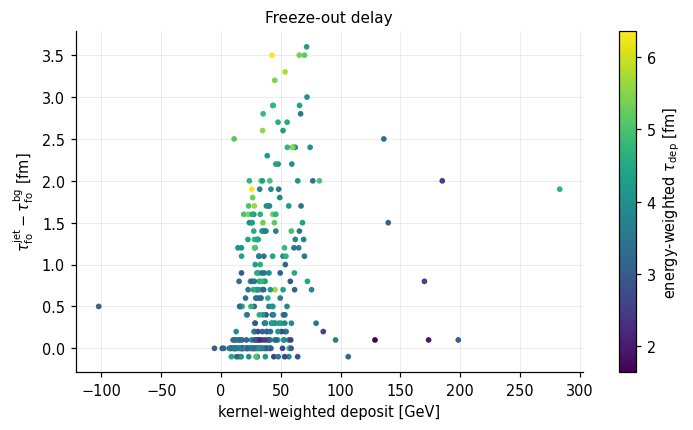

In [11]:
tmean = (D.tau_dep * D.E_inj.clip(0)).groupby(D.event).sum() / D.E_inj.clip(0).groupby(D.event).sum().clip(1e-9)
fig, ax = plt.subplots(figsize=(6.2, 3.8), constrained_layout=True)
sc = ax.scatter(E.E_inj_hydro, E.dtau_fo, c=tmean.reindex(E.index), cmap="viridis", s=14, lw=0)
fig.colorbar(sc, ax=ax, label=r"energy-weighted $\tau_\mathrm{dep}$ [fm]")
tidy(ax, "kernel-weighted deposit [GeV]", r"$\tau_\mathrm{fo}^\mathrm{jet} - \tau_\mathrm{fo}^\mathrm{bg}$ [fm]",
     "Freeze-out delay")
plt.show()

## 10. What to take from this

The numbers are for `AuAu_0_10_pth10-40_eta06`: 300 events, 100 per pTHat window, 805
midrapidity partons, with the LBT double-count fix applied. Profiles are unweighted
(`USE_XSEC_WEIGHTS = False`).

- **The bookkeeping is exact.** Every droplet is assigned to its shower through the graph. Per
  shower, $E_0 = E_\text{surv} + \Delta E$ holds to $10^{-13}$ GeV.
- **MUSIC_2 does not receive the droplets' energy (§1).** The point-sampled kernel gives
  27% of the droplets a flux outside [0.8, 1.2]. Per event, the injected energy is 0.68–1.12
  of the droplet energy (16–84%), with extremes of −1.9 and 6.0. 40% of events are off by more
  than 20%.
  - It is worst at $|\eta_s| > 1$, where 38% of the energy is deposited, and at late τ.
  - The wake follows the kernel-weighted deposit (correlation 0.92), not the droplet energy
    (0.52).
  - This needs fixing in the source (normalize each droplet's sampled kernel to 1) before
    hydro-level results can be compared with the deposited energy. Until then §7–§9 describe
    the wake MUSIC actually evolved.
- **Loss vs pT (§2).** $\Delta E/E_0$ falls from ~1 below 5 GeV (those partons are absorbed
  whole) to ~0.3 (quarks) and ~0.45 (gluons) at 40 GeV.
  - Above 10 GeV the fraction is 0.41 for quarks and 0.65 for gluons. The ratio 1.6 is below
    $C_A/C_F$ = 2.25, as expected once most soft partons are absorbed entirely.
  - The holes are 28% of the absorbed energy above 10 GeV.
- **Geometry (§3).** The loss falls with the vertex's distance from the centre. At 20–45 GeV,
  partons heading out ($\cos\alpha > 0$) lose ~0.4 of their energy, against ~0.5 for those
  heading in. In 0–10% ($\varepsilon_2$ = 0.03–0.35) there is no significant in-plane vs
  out-of-plane difference.
- **Path length (§4).** At 20–45 GeV, ΔE rises from ~7 GeV at L = 2.5 fm to ~21 GeV at 8.5 fm.
  - All line integrals correlate with ΔE at ~0.3. With 800 partons this sample cannot say
    whether L, T², T³ or the L²-weighted T³ orders the loss best.
  - The flow-weighted versions correlate less, not more. The flow along the path is
    $\langle v\cdot n\rangle \approx 0.25$.
- **Dijets (§5).** The medium adds asymmetry toward the leg with the shorter path:
  $\langle A_J^\text{surv} - A_J^\text{ini}\rangle$ = +0.37 at $L_1 - L_2 \approx -5$ fm and
  −0.36 at +5 fm.
- **Deposition (§6).** Most energy goes in at $\tau_\text{dep}$ = 2–4 fm, at background
  T = 0.17–0.25 GeV. 10% of the positive deposit is below $T_c$, and 0.08% arrives after
  MUSIC_2 stopped. Longer paths deposit later.
- **The wake (§7).**
  - Energy: $\Delta P^0$ follows the kernel-weighted deposit to within ~2% until τ ≈ 8 fm,
    then falls as the wake leaves the $|x|, |y| < 10$ fm window. The ideal-fluid $T^{\mu\nu}$
    also misses the viscous part.
  - Momentum: the wake's momentum along the deposit is 0.94 of it.
  - Entropy: $\Delta S$ = 0.93 × $\sum (p\cdot u)/T$, against 0.54 × $\sum E/T$. So the deposit
    thermalizes in the flowing medium, as a hydrodynamic source should.
- **Jet frame (§8).**
  - While the leg deposits, 46% of the wake energy sits behind the source (135°–225°): a peak
    directly behind and side lobes near ±55° from 180°. The static Mach half-angle at the
    source is 23°, and the flow opens it.
  - Directly behind the source the momentum along the jet is negative: that is where the holes
    go in.
  - At the last frame the energy is ahead of the last deposit (46% within 45°): the wake has
    moved on past the parked source.
- **Freeze-out (§9).** The jet delays freeze-out by 0.75 fm on average and by up to 3.6 fm.
  The delay correlates more with *when* the energy went in (0.54) than with how much (0.28).

**Caveats.**
- The samples are small: 300 events, 800 midrapidity partons.
- Paths are straight lines at the parton's rapidity.
- The angles in §8 are spatial, not hadron momenta.
- Every hydro-level number carries the kernel-flux problem of §1.